# 1. Distance to Nearest Urban Farm

In [33]:
import geopandas as gpd
import numpy as np

# Load GeoPackage
gdf = gpd.read_file("dallas_modeling_final.gpkg")

#variable to test
variable = "distance_to_nearest_uf"

# Keep only valid, nonmissing observations
gdf = gdf[gdf.geometry.notna() & gdf[variable].notna()].copy()
gdf = gdf.reset_index(drop=True)

# Convert variable to numeric
gdf[variable] = gdf[variable].astype(float)

In [34]:
gdf.columns.tolist()

['COUNTY',
 'GEOID',
 'tract',
 'walking_ind',
 'walkind_inv_perc',
 'total_pop',
 'total_pop_moe',
 'below_200_fed_poverty_percentage',
 'no_hs_diploma',
 'uninsured',
 'E_CHD',
 'E_DIABETES',
 'E_AFAM',
 'E_ASIAN',
 'E_HISP',
 'median_age',
 'ALAND',
 'AWATER',
 'distance_to_nearest_grocery',
 'distance_to_nearest_fm',
 'distance_to_nearest_uf',
 'median_income',
 'pct_no_vehicle',
 'geometry']

Question: Are places with similar values located near each other?
Analysis: First, neighboring areas will be identified, their values will be compared, and then tested to see if the observed pattern is more clustered than would be expected if the values were randomly distributed.

In [35]:
gdf["geometry"] = gdf.geometry.make_valid()

Queen contiguity: polygons touching by an edge or a corner-- if tracts are similar or different 

In [36]:
#Queen-continguity weights
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

#neighbors
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

In [37]:
#row-standardize weights- each neighbor sum to 1
row_sums = W.sum(axis=1)

W_standardized = np.divide(
    W,
    row_sums[:, None],
    out=np.zeros_like(W),
    where=row_sums[:, None] != 0
)

In [38]:
#calculate global moran's I
x = gdf[variable].to_numpy()

x_mean = x.mean()
z = x - x_mean

n = len(x)
S0 = W_standardized.sum()

numerator = np.sum(W_standardized * np.outer(z, z))
denominator = np.sum(z ** 2)

morans_I = (n / S0) * (numerator / denominator)

expected_I = -1 / (n - 1)

print("Global Moran's I:", morans_I)
print("Expected I under spatial randomness:", expected_I)

Global Moran's I: 0.9171436017365515
Expected I under spatial randomness: -0.0014970059880239522


Interpretation: there is postitive spatial clustering suggested here. High values are near other high values; low values are near other low values.

Moran’s I above the expected value suggests positive spatial clustering.
Moran’s I below the expected value suggests spatial dispersion.
Moran’s I near the expected value suggests little spatial autocorrelation.

In [39]:
#permutation p-value 
rng = np.random.default_rng(42)

n_permutations = 999
permuted_I = np.empty(n_permutations)

for p in range(n_permutations):
    shuffled_z = rng.permutation(z)

    permuted_numerator = np.sum(
        W_standardized * np.outer(shuffled_z, shuffled_z)
    )

    permuted_I[p] = (
        (n / S0)
        * (permuted_numerator / denominator)
    )

# Two-sided pseudo p-value
extreme_count = np.sum(
    np.abs(permuted_I - expected_I)
    >= np.abs(morans_I - expected_I)
)

p_value = (extreme_count + 1) / (n_permutations + 1)

print("Permutation p-value:", p_value)

Permutation p-value: 0.001


The p-value is less than 0.05, indicating that the observed spatial pattern is unlikely to have occurred by random chance. Therefore, we reject the null hypothesis of spatial randomness and conclude that the variable exhibits statistically significant spatial autocorrelation.

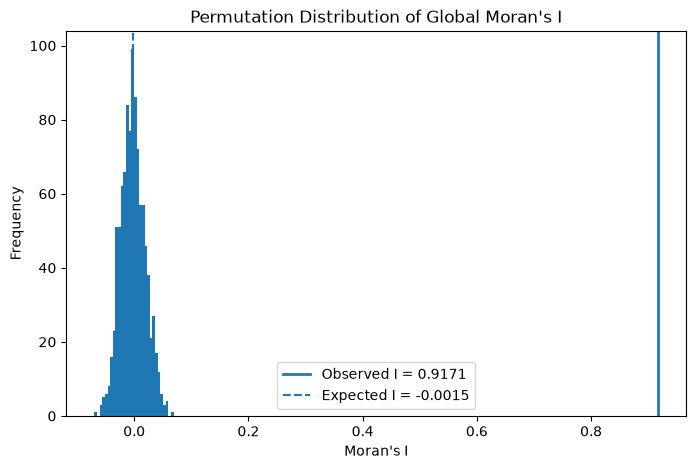

In [40]:
#permutation-distribution plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(permuted_I, bins=30)
plt.axvline(morans_I, linewidth=2, label=f"Observed I = {morans_I:.4f}")
plt.axvline(expected_I, linestyle="--", label=f"Expected I = {expected_I:.4f}")
plt.xlabel("Moran's I")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of Global Moran's I")
plt.legend()
plt.show()

The permutation distribution represents the Moran's I values expected under the null hypothesis of spatial randomness. The observed Moran's I (0.9171) lies far to the right of the permutation distribution, indicating statistically significant positive spatial autocorrelation and suggesting that the observed spatial pattern is unlikely to have occurred by chance.

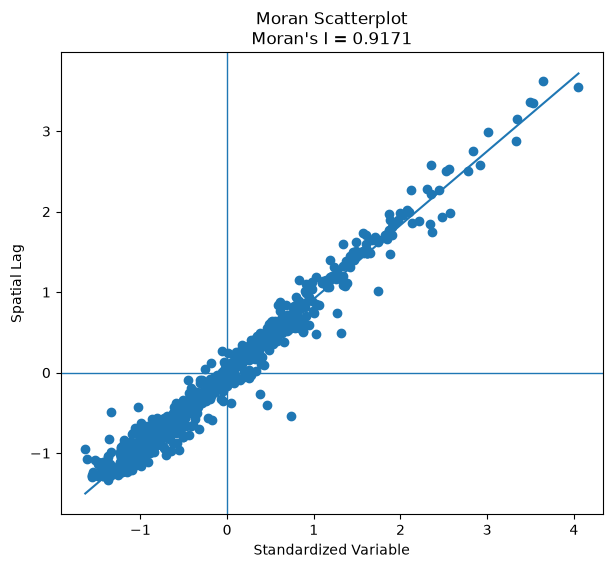

In [41]:
#moran scatterplot
# Standardize the variable
z_standardized = (x - x.mean()) / x.std(ddof=0)

# Spatial lag
spatial_lag = W_standardized @ z_standardized

plt.figure(figsize=(7, 6))
plt.scatter(z_standardized, spatial_lag)

# Regression line
slope, intercept = np.polyfit(z_standardized, spatial_lag, 1)
x_line = np.linspace(z_standardized.min(), z_standardized.max(), 100)

plt.plot(
    x_line,
    intercept + slope * x_line
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Standardized Variable")
plt.ylabel("Spatial Lag")
plt.title(f"Moran Scatterplot\nMoran's I = {morans_I:.4f}")
plt.show()

The Moran scatterplot shows a positive relationship between each observation's standardized value and the average value of its neighboring observations. The positive slope of the fitted line (Moran's I = 0.9171) indicates that areas with high values tend to be located near other high-value areas, while areas with low values tend to be located near other low-value areas.

# 2. Heart Disease Outcomes

In [42]:
variable = "E_CHD"

In [43]:
#Queen-continguity weights
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

#neighbors
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

In [44]:
#row-standardize weights- each neighbor sum to 1
row_sums = W.sum(axis=1)

W_standardized = np.divide(
    W,
    row_sums[:, None],
    out=np.zeros_like(W),
    where=row_sums[:, None] != 0
)

In [45]:
#calculate global moran's I
x = gdf[variable].to_numpy()

x_mean = x.mean()
z = x - x_mean

n = len(x)
S0 = W_standardized.sum()

numerator = np.sum(W_standardized * np.outer(z, z))
denominator = np.sum(z ** 2)

morans_I = (n / S0) * (numerator / denominator)

expected_I = -1 / (n - 1)

print("Global Moran's I:", morans_I)
print("Expected I under spatial randomness:", expected_I)

Global Moran's I: -0.004926411580165698
Expected I under spatial randomness: -0.0014970059880239522


In [46]:
#permutation p-value 
rng = np.random.default_rng(42)

n_permutations = 999
permuted_I = np.empty(n_permutations)

for p in range(n_permutations):
    shuffled_z = rng.permutation(z)

    permuted_numerator = np.sum(
        W_standardized * np.outer(shuffled_z, shuffled_z)
    )

    permuted_I[p] = (
        (n / S0)
        * (permuted_numerator / denominator)
    )

# Two-sided pseudo p-value
extreme_count = np.sum(
    np.abs(permuted_I - expected_I)
    >= np.abs(morans_I - expected_I)
)

p_value = (extreme_count + 1) / (n_permutations + 1)

print("Permutation p-value:", p_value)

Permutation p-value: 1.0


The p-value is more than 0.05, indicating that the observed spatial pattern is likely to have occurred by random chance. 

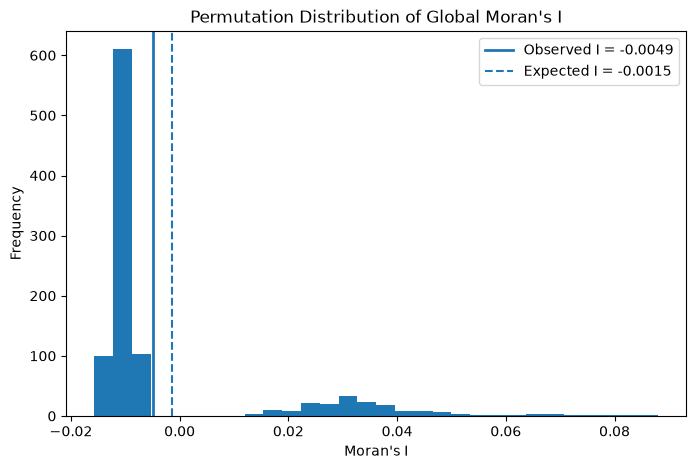

In [47]:
#permutation-distribution plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(permuted_I, bins=30)
plt.axvline(morans_I, linewidth=2, label=f"Observed I = {morans_I:.4f}")
plt.axvline(expected_I, linestyle="--", label=f"Expected I = {expected_I:.4f}")
plt.xlabel("Moran's I")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of Global Moran's I")
plt.legend()
plt.show()

The permutation distribution represents the Moran's I values expected under the null hypothesis of spatial randomness. The observed Moran's I (-0.002664304759787917)is slighlty to the right of the expected value, indicating non statistically significant positive spatial autocorrelation and suggesting that the observed spatial pattern is likely to have occurred by chance.

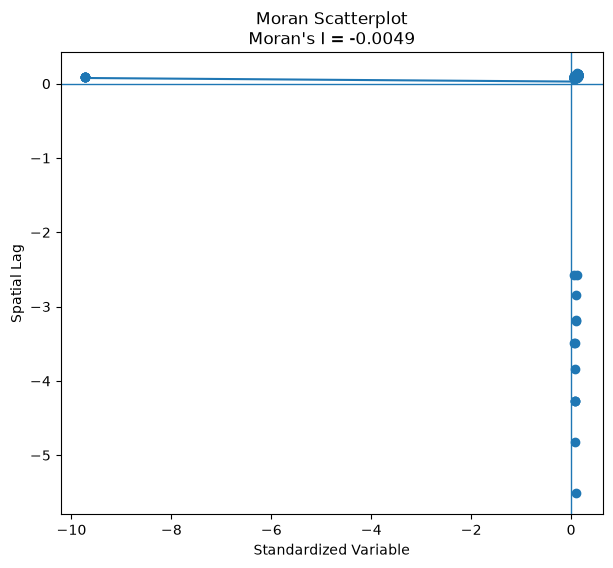

In [48]:
#moran scatterplot
# Standardize the variable
z_standardized = (x - x.mean()) / x.std(ddof=0)

# Spatial lag
spatial_lag = W_standardized @ z_standardized

plt.figure(figsize=(7, 6))
plt.scatter(z_standardized, spatial_lag)

# Regression line
slope, intercept = np.polyfit(z_standardized, spatial_lag, 1)
x_line = np.linspace(z_standardized.min(), z_standardized.max(), 100)

plt.plot(
    x_line,
    intercept + slope * x_line
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Standardized Variable")
plt.ylabel("Spatial Lag")
plt.title(f"Moran Scatterplot\nMoran's I = {morans_I:.4f}")
plt.show()


The Moran scatterplot shows a positive relationship between each observation's standardized value and the average value of its neighboring observations. The near-zero slope of the fitted line shows little spatial autocorrelation.

# 3. Diabetes Outcomes

In [49]:
variable = "E_DIABETES"

In [50]:
#Queen-continguity weights
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

#neighbors
n = len(gdf)

# Empty spatial weights matrix
W = np.zeros((n, n))

# Spatial index makes this faster than comparing every polygon
spatial_index = gdf.sindex

for i, geom_i in enumerate(gdf.geometry):
    # Find geometries whose bounding boxes overlap
    possible_neighbors = list(spatial_index.intersection(geom_i.bounds))

    for j in possible_neighbors:
        if i == j:
            continue

        geom_j = gdf.geometry.iloc[j]

        # Queen contiguity: polygons touch at an edge or corner
        if geom_i.touches(geom_j):
            W[i, j] = 1

In [51]:
#row-standardize weights- each neighbor sum to 1
row_sums = W.sum(axis=1)

W_standardized = np.divide(
    W,
    row_sums[:, None],
    out=np.zeros_like(W),
    where=row_sums[:, None] != 0
)

In [52]:
#calculate global moran's I
x = gdf[variable].to_numpy()

x_mean = x.mean()
z = x - x_mean

n = len(x)
S0 = W_standardized.sum()

numerator = np.sum(W_standardized * np.outer(z, z))
denominator = np.sum(z ** 2)

morans_I = (n / S0) * (numerator / denominator)

expected_I = -1 / (n - 1)

print("Global Moran's I:", morans_I)
print("Expected I under spatial randomness:", expected_I)

Global Moran's I: -0.002664304759787917
Expected I under spatial randomness: -0.0014970059880239522


In [53]:
#permutation p-value 
rng = np.random.default_rng(42)

n_permutations = 999
permuted_I = np.empty(n_permutations)

for p in range(n_permutations):
    shuffled_z = rng.permutation(z)

    permuted_numerator = np.sum(
        W_standardized * np.outer(shuffled_z, shuffled_z)
    )

    permuted_I[p] = (
        (n / S0)
        * (permuted_numerator / denominator)
    )

# Two-sided pseudo p-value
extreme_count = np.sum(
    np.abs(permuted_I - expected_I)
    >= np.abs(morans_I - expected_I)
)

p_value = (extreme_count + 1) / (n_permutations + 1)

print("Permutation p-value:", p_value)

Permutation p-value: 1.0


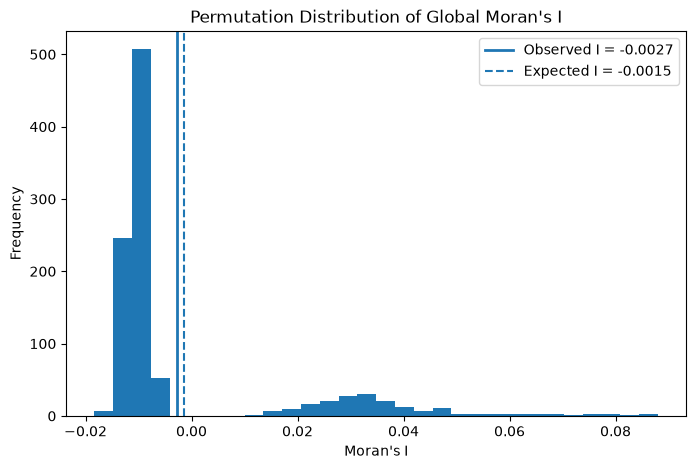

In [54]:
#permutation-distribution plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(permuted_I, bins=30)
plt.axvline(morans_I, linewidth=2, label=f"Observed I = {morans_I:.4f}")
plt.axvline(expected_I, linestyle="--", label=f"Expected I = {expected_I:.4f}")
plt.xlabel("Moran's I")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of Global Moran's I")
plt.legend()
plt.show()

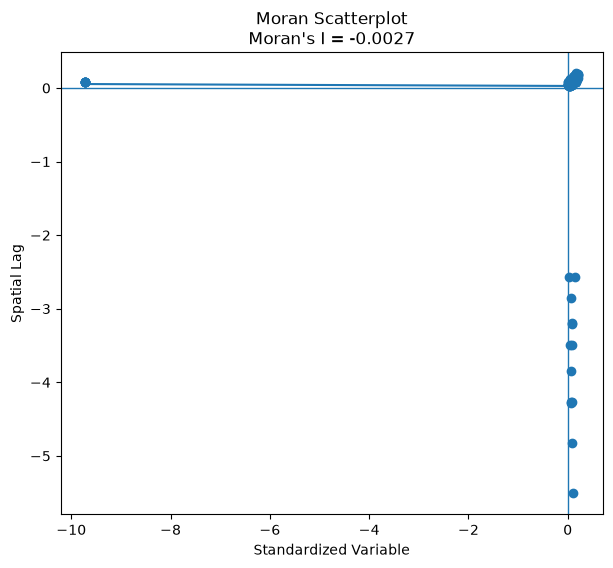

In [55]:
#moran scatterplot
# Standardize the variable
z_standardized = (x - x.mean()) / x.std(ddof=0)

# Spatial lag
spatial_lag = W_standardized @ z_standardized

plt.figure(figsize=(7, 6))
plt.scatter(z_standardized, spatial_lag)

# Regression line
slope, intercept = np.polyfit(z_standardized, spatial_lag, 1)
x_line = np.linspace(z_standardized.min(), z_standardized.max(), 100)

plt.plot(
    x_line,
    intercept + slope * x_line
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Standardized Variable")
plt.ylabel("Spatial Lag")
plt.title(f"Moran Scatterplot\nMoran's I = {morans_I:.4f}")
plt.show()
